ASSIGNMENT 7

Creating and Fixing Mode Collapse in a GAN

Objective

The objective of this assignment is to understand mode collapse, a common problem in Generative Adversarial Networks (GANs). In this assignment, we intentionally make the GAN training unstable so that the generator produces very similar images. Then, we apply a technique to improve the generated output.

Task 1: Import Libraries


First, we import the required Python libraries. TensorFlow is used to build and train the GAN, while Matplotlib is used to display the generated images.

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


Task 2: Load and Prepare the Dataset

We will use the MNIST handwritten digit dataset. It contains images of handwritten digits from 0 to 9.

In [4]:
# Load MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize images between -1 and 1
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)

print("Training images shape:", x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28, 1)


In [5]:
BUFFER_SIZE = 60000
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

Task 3: Create the Generator

The generator takes random noise and creates a fake handwritten digit.
For the mode collapse experiment, we deliberately reduce the generator's capacity and remove batch normalization.

In [6]:
def create_generator():
    model = tf.keras.Sequential([

        tf.keras.layers.Dense(7 * 7 * 64, use_bias=True, input_shape=(100,)),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Reshape((7, 7, 64)),

        tf.keras.layers.Conv2DTranspose(
            32, kernel_size=5, strides=2,
            padding="same", use_bias=True
        ),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(
            1, kernel_size=5, strides=2,
            padding="same", activation="tanh"
        )
    ])

    return model

generator = create_generator()

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3136)           │       316,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 32)     │        51,232 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │           801 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 368,769 (1.41 MB)

 Trainable params: 368,769 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Create the Discriminator

The discriminator decides whether an image is real or fake.

In [7]:
def create_discriminator():
    model = tf.keras.Sequential([

        tf.keras.layers.Conv2D(
            32, kernel_size=5, strides=2,
            padding="same",
            input_shape=[28, 28, 1]
        ),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(
            64, kernel_size=5, strides=2,
            padding="same"
        ),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1)
    ])

    return model

discriminator = create_discriminator()

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,233 (215.75 KB)

 Trainable params: 55,233 (215.75 KB)

 Non-trainable params: 0 (0.00 B)

Task 5: Create Loss Functions

We use Binary Cross-Entropy to calculate the error of the generator and discriminator.

In [8]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss


def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

Task 6: Create Optimizers

Important

To deliberately make the GAN unstable, we use a very high learning rate.
This is the modification that we use to create the mode-collapse experiment.

In [9]:
# High learning rate deliberately used to make training unstable
learning_rate = 0.01

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate
)

A normal GAN generally uses a much smaller learning rate. The high learning rate can make the generator and discriminator update too aggressively, making training unstable and increasing the possibility of mode collapse.

Task 7: Train the GAN

We train the modified GAN for approximately 20 epochs.

In [10]:
EPOCHS = 20
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal(
    [num_examples_to_generate, noise_dim]
)

In [11]:
@tf.function
def train_step(images):

    noise = tf.random.normal(
        [BATCH_SIZE, noise_dim]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

Task 8: Display Generated Images

In [12]:
def generate_and_display_images(model, epoch, test_input):

    predictions = model(
        test_input,
        training=False
    )

    fig = plt.figure(figsize=(8, 8))

    for i in range(predictions.shape[0]):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            predictions[i, :, :, 0] * 127.5 + 127.5,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        "Generated Images - Epoch " + str(epoch)
    )

    plt.show()

Task 9: Train the Modified GAN

Epoch 1/20 | Generator Loss: 10.7102 | Discriminator Loss: 0.0931
Epoch 2/20 | Generator Loss: 11.5603 | Discriminator Loss: 0.0169
Epoch 3/20 | Generator Loss: 21.5242 | Discriminator Loss: 0.0263
Epoch 4/20 | Generator Loss: 21.2941 | Discriminator Loss: 0.0802
Epoch 5/20 | Generator Loss: 25.8318 | Discriminator Loss: 0.0107


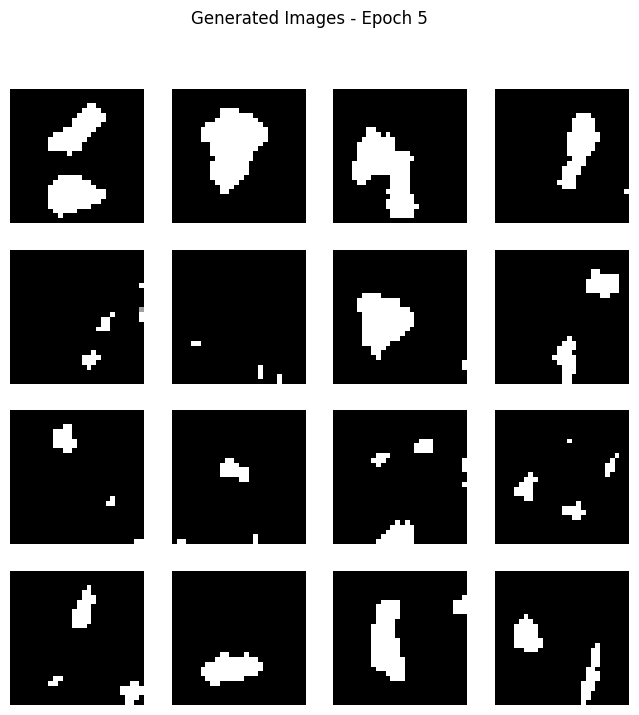

Epoch 6/20 | Generator Loss: 20.4634 | Discriminator Loss: 0.0012
Epoch 7/20 | Generator Loss: 20.7304 | Discriminator Loss: 0.0109
Epoch 8/20 | Generator Loss: 25.3767 | Discriminator Loss: 0.0001
Epoch 9/20 | Generator Loss: 160.3567 | Discriminator Loss: 0.0002
Epoch 10/20 | Generator Loss: 143.8821 | Discriminator Loss: 0.0000


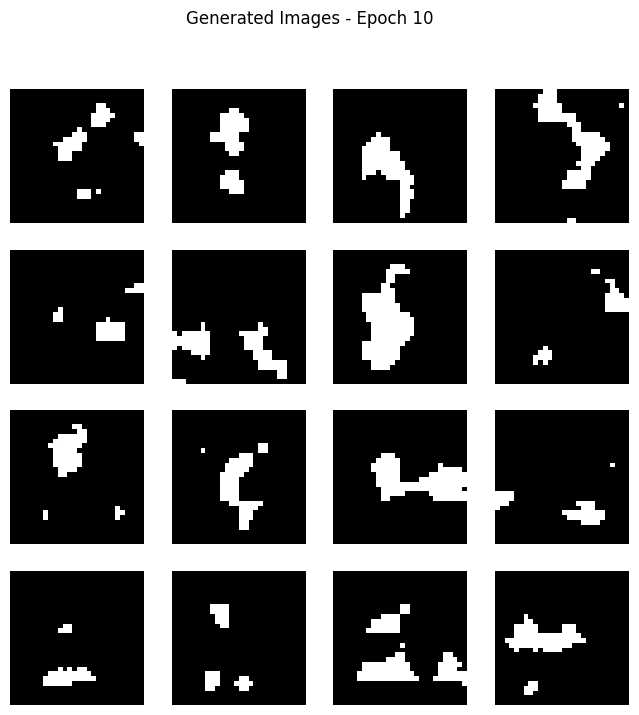

Epoch 11/20 | Generator Loss: 106.2091 | Discriminator Loss: 0.3759
Epoch 12/20 | Generator Loss: 87.8534 | Discriminator Loss: 0.0224
Epoch 13/20 | Generator Loss: 100.4947 | Discriminator Loss: 0.0000
Epoch 14/20 | Generator Loss: 362.7347 | Discriminator Loss: 0.0000
Epoch 15/20 | Generator Loss: 302.9349 | Discriminator Loss: 0.0000


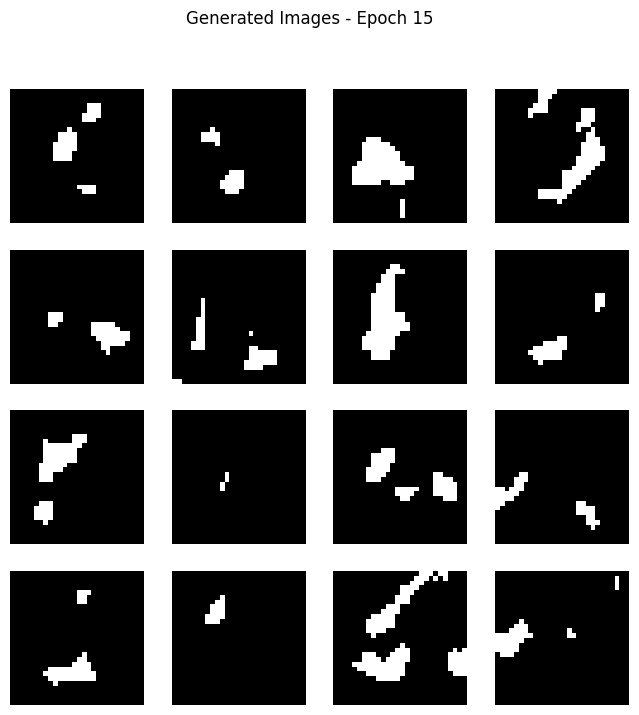

Epoch 16/20 | Generator Loss: 290.4600 | Discriminator Loss: 0.0000
Epoch 17/20 | Generator Loss: 281.8107 | Discriminator Loss: 0.0000
Epoch 18/20 | Generator Loss: 268.0930 | Discriminator Loss: 0.0681
Epoch 19/20 | Generator Loss: 227.5963 | Discriminator Loss: 0.8320
Epoch 20/20 | Generator Loss: 302.0284 | Discriminator Loss: 1.5075


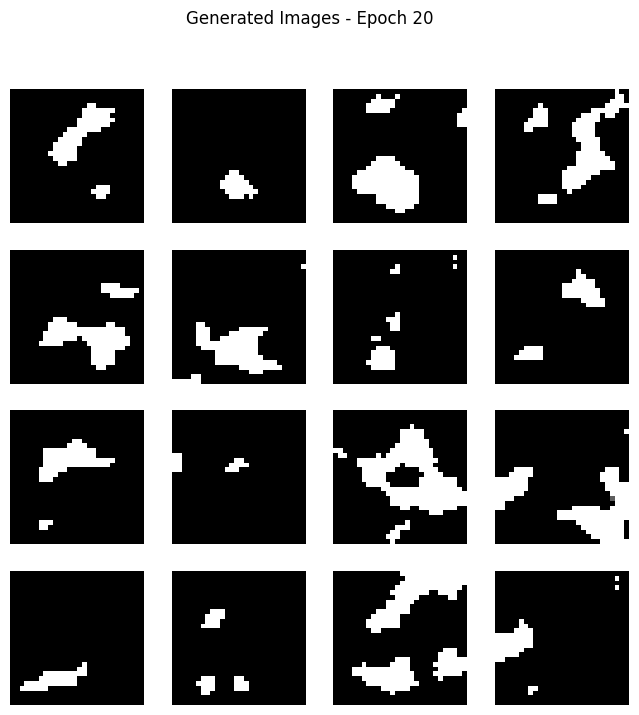

In [13]:
for epoch in range(EPOCHS):

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(image_batch)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Generator Loss: {gen_loss:.4f} | "
        f"Discriminator Loss: {disc_loss:.4f}"
    )

    if (epoch + 1) % 5 == 0:
        generate_and_display_images(
            generator,
            epoch + 1,
            seed
        )

Task 10: Apply a Technique to Improve Mode Collapse

For the improvement, we will use:
Different Learning Rates for Generator and Discriminator
Instead of giving both networks the same high learning rate, we use:
- Generator learning rate = 0.0002
- Discriminator learning rate = 0.0001
This gives the two networks different update speeds and can make training more stable.

Task 11: Reset the Models

We create fresh models so that the improved experiment starts from the beginning.

In [14]:
generator = create_generator()
discriminator = create_discriminator()

Task 12: Use Different Learning Rates

In [15]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001,
    beta_1=0.5
)

Task 13: Train the Improved GAN

Epoch 1/20 | Generator Loss: 290.4788 | Discriminator Loss: 0.0000
Epoch 2/20 | Generator Loss: 546.5983 | Discriminator Loss: 0.2644
Epoch 3/20 | Generator Loss: 538.3754 | Discriminator Loss: 0.0000
Epoch 4/20 | Generator Loss: 663.2949 | Discriminator Loss: 0.0000
Epoch 5/20 | Generator Loss: 606.7400 | Discriminator Loss: 0.5107


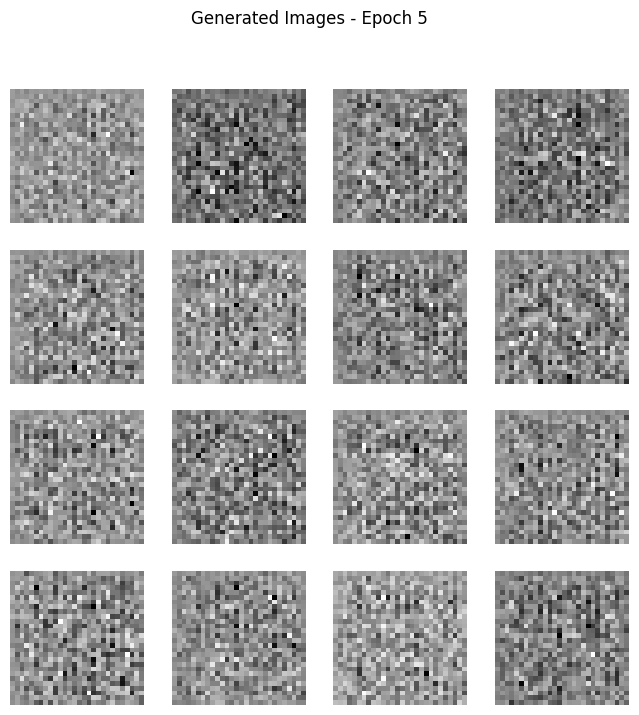

Epoch 6/20 | Generator Loss: 667.6338 | Discriminator Loss: 0.0000
Epoch 7/20 | Generator Loss: 824.0167 | Discriminator Loss: 0.7613
Epoch 8/20 | Generator Loss: 931.8289 | Discriminator Loss: 0.0000
Epoch 9/20 | Generator Loss: 731.6773 | Discriminator Loss: 3.0753
Epoch 10/20 | Generator Loss: 919.1659 | Discriminator Loss: 0.0000


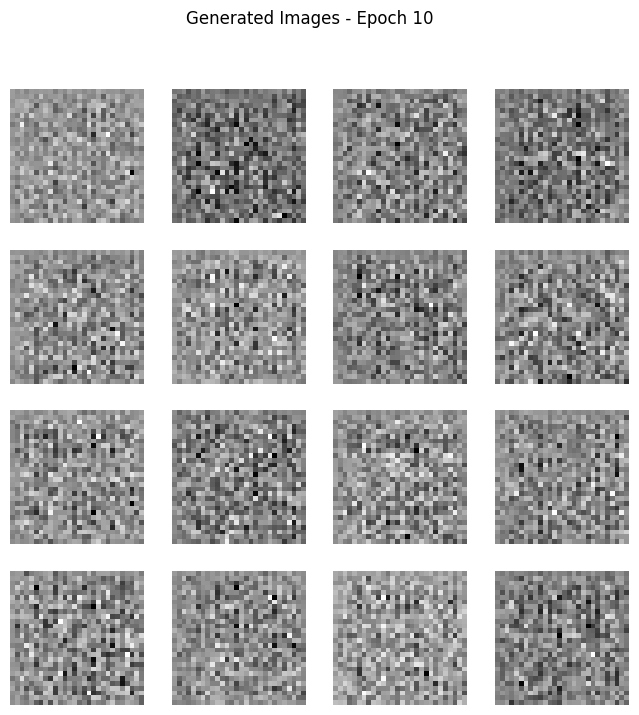

Epoch 11/20 | Generator Loss: 2184.6631 | Discriminator Loss: 3.8161
Epoch 12/20 | Generator Loss: 1398.0658 | Discriminator Loss: 0.0000
Epoch 13/20 | Generator Loss: 1519.6953 | Discriminator Loss: 0.0000
Epoch 14/20 | Generator Loss: 1026.8491 | Discriminator Loss: 1.6519
Epoch 15/20 | Generator Loss: 1570.9580 | Discriminator Loss: 0.0000


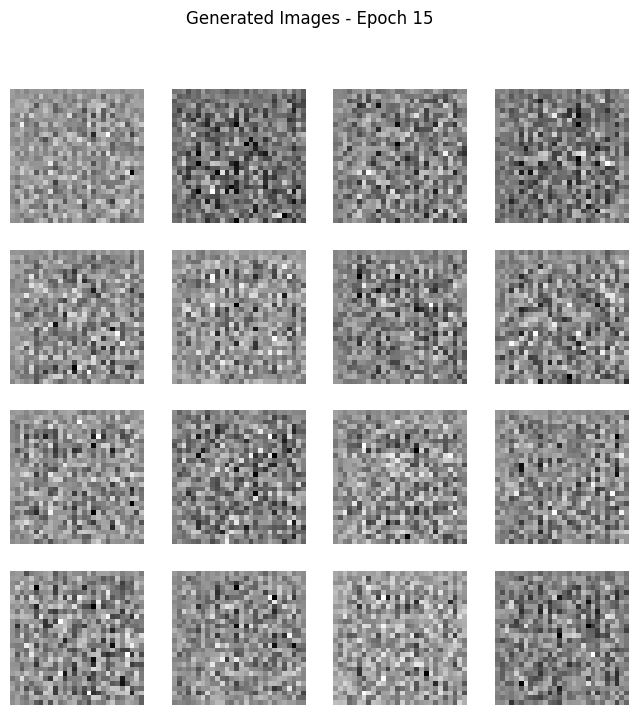

Epoch 16/20 | Generator Loss: 1639.5355 | Discriminator Loss: 0.0000
Epoch 17/20 | Generator Loss: 2083.4155 | Discriminator Loss: 0.0000
Epoch 18/20 | Generator Loss: 2430.4199 | Discriminator Loss: 0.0000
Epoch 19/20 | Generator Loss: 1490.2145 | Discriminator Loss: 0.0000
Epoch 20/20 | Generator Loss: 2846.7202 | Discriminator Loss: 0.0000


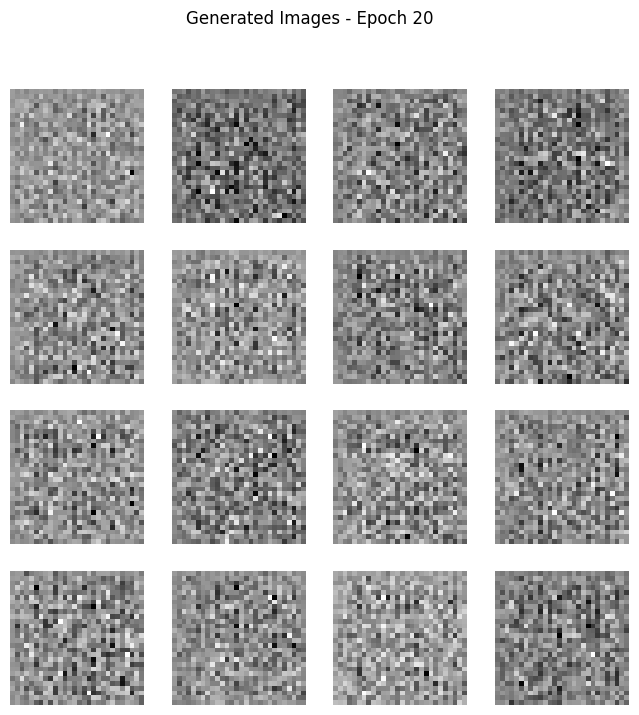

In [16]:
EPOCHS = 20

for epoch in range(EPOCHS):

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(image_batch)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Generator Loss: {gen_loss:.4f} | "
        f"Discriminator Loss: {disc_loss:.4f}"
    )

    if (epoch + 1) % 5 == 0:
        generate_and_display_images(
            generator,
            epoch + 1,
            seed
        )

Before applying the improvement

The GAN was trained using a very high learning rate of 0.01. This made the training unstable. The generator may produce images that are very similar to each other.

After applying the improvement

Different learning rates were used for the generator and discriminator. The smaller learning rates make the training more stable, allowing the generator to learn different patterns from the training data.